In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import date
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_gdd_and_yield, \
    plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import jablje_soil_layers, jablje_curve_number, \
    jablje_readily_evaporable_water, jablje_maize_params, jablje_optimal_management, jablje_initial_cond, \
    jablje_groundwater
from aquacrop_slovenia.diagnostics import nse, kge, mkge, compute_annual_gdd

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
# Set up working directory for outputs
output_dir = config.RAMDISK_DIR / "testing"
LOCATION = "jablje"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

We exclude 2017 since we dont have ET data for most of the year

In [4]:
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 10, 10),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
for year in range(1993, 2024) if year not in [2017]]

In [5]:
jablje_temperatures, jablje_eto, jablje_rain = get_station_weather(8) # Jablje uses ARSO meteo station 8 data

In [6]:
historical_co2 = get_co2_for_aquacrop("historical")

In [7]:
jablje_weather = Weather(
    location=LOCATION,
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [8]:
jablje_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=jablje_maize_params
)

In [9]:
jablje_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [10]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=jablje_weather,
    #ground_water=jablje_groundwater,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [11]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: E:\aquacrop\testing
Running AquaCrop simulation with project file: E:\aquacrop\testing\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\testing\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [12]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,765.3,723.8,1461.8,355.97,0.0,624.2,...,34.8,7.933,10.439,2.15,0.0,0.0,10,10,1993,PROJECT.PRM
1,2,1,1,1994,1019.4,706.5,1567.8,357.58,0.0,861.9,...,46.1,10.158,13.366,2.37,0.0,0.0,10,10,1994,PROJECT.PRM
2,3,1,1,1995,1199.6,647.7,1335.5,359.53,0.0,916.6,...,46.0,10.302,13.556,2.68,0.0,0.0,10,10,1995,PROJECT.PRM
3,4,1,1,1996,1087.0,603.8,1323.1,361.26,0.0,832.0,...,38.6,8.755,11.520,2.46,0.0,0.0,10,10,1996,PROJECT.PRM
4,5,1,1,1997,740.0,683.6,1437.8,362.43,0.0,652.7,...,44.3,10.602,13.949,2.61,0.0,0.0,10,10,1997,PROJECT.PRM
5,6,1,1,1998,1068.3,671.4,1545.9,365.14,0.0,857.3,...,40.3,8.798,11.576,2.50,0.0,0.0,10,10,1998,PROJECT.PRM
6,7,1,1,1999,1089.3,642.0,1562.4,366.96,0.0,878.9,...,46.1,10.926,14.376,2.74,0.0,0.0,10,10,1999,PROJECT.PRM
7,8,1,1,2000,869.7,704.3,1541.4,368.25,0.0,743.1,...,42.0,9.821,12.922,2.34,0.0,0.0,10,10,2000,PROJECT.PRM
8,9,1,1,2001,1054.2,661.7,1491.7,369.65,0.0,836.9,...,46.1,10.400,13.684,2.56,0.0,0.0,10,10,2001,PROJECT.PRM
9,10,1,1,2002,865.7,643.0,1492.1,371.87,0.0,748.1,...,43.7,10.204,13.427,2.59,0.0,0.0,10,10,2002,PROJECT.PRM


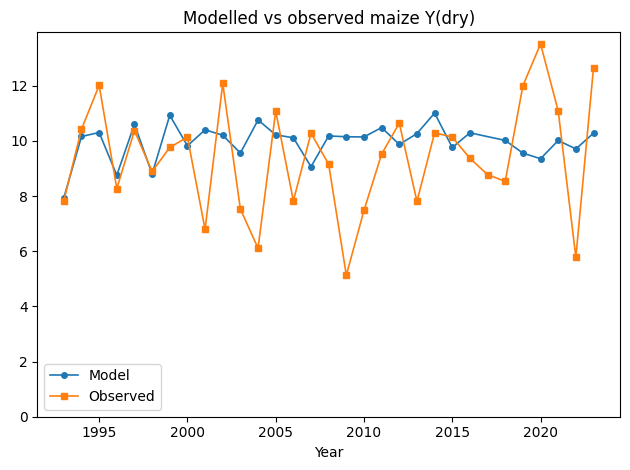

In [13]:
plot_yield_timeseries_comparison(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

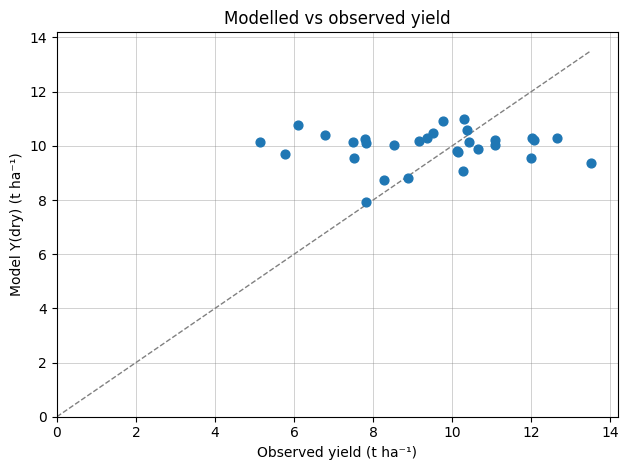

In [14]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"))

In [15]:
print(root_mean_squared_error(results["season"][["Year1", "Y(dry)"]], get_yield_for_comparison(LOCATION, "grain", "A", "N3")))
print(r2_score(results["season"][["Year1", "Y(dry)"]], get_yield_for_comparison(LOCATION, "grain", "A", "N3")))
print(nse(results["season"]["Y(dry)"].values, get_yield_for_comparison(LOCATION, "grain", "A", "N3")["yield"].values))
print(kge(results["season"]["Y(dry)"].values, get_yield_for_comparison(LOCATION, "grain", "A", "N3")["yield"].values))
print(mkge(results["season"]["Y(dry)"].values, get_yield_for_comparison(LOCATION, "grain", "A", "N3")["yield"].values))

1.0978741769134264
-4.644521598220345
-0.14504861026892657
-0.17836929705356197
-0.1884520452372629


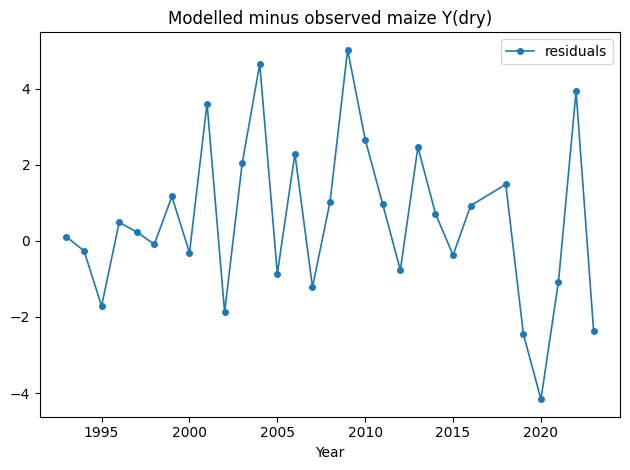

In [16]:
plot_yield_timeseries_residuals(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

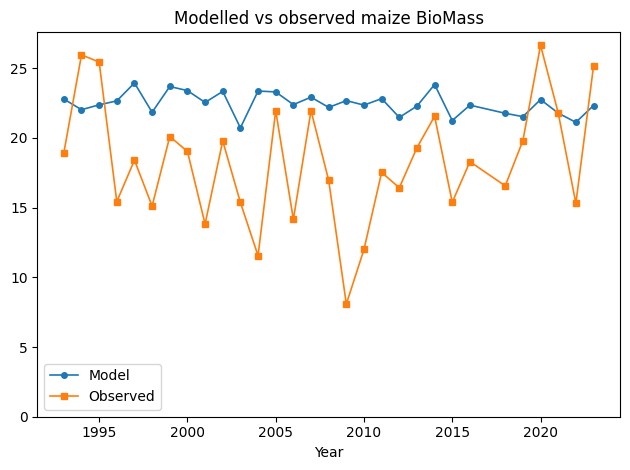

In [17]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass")

3.0003780234052733
-27.13078533423004
-0.9099783381045983
-0.1919065030893592
-0.2157433079751485


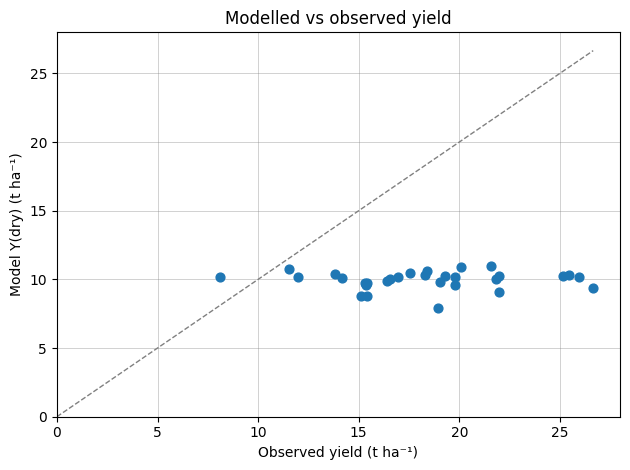

In [18]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "biomass", "A", "N3"))
print(root_mean_squared_error(results["season"][["Year1", "BioMass"]],
                              get_yield_for_comparison(LOCATION, "biomass", "A", "N3")))
print(r2_score(results["season"][["Year1", "BioMass"]], get_yield_for_comparison(LOCATION, "biomass", "A", "N3")))
print(nse(results["season"]["BioMass"].values, get_yield_for_comparison(LOCATION, "biomass", "A", "N3")["yield"].values))
print(kge(results["season"]["BioMass"].values, get_yield_for_comparison(LOCATION, "biomass", "A", "N3")["yield"].values))
print(mkge(results["season"]["BioMass"].values, get_yield_for_comparison(LOCATION, "biomass", "A", "N3")["yield"].values))

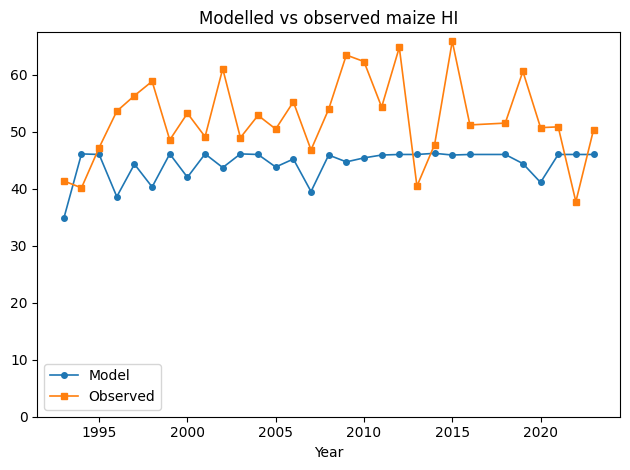

In [19]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "hi", "A", "N3"), "HI")

In [20]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(2.30),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,758.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,758.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,757.4,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,757.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,756.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,6,10,1993,-9,0,759.7,2.4,0.0,0.0,2.4,...,None,None,None,None,None,None,None,None,None,None
279,7,10,1993,-9,0,781.7,47.0,0.0,0.0,24.6,...,None,None,None,None,None,None,None,None,None,None
280,8,10,1993,-9,0,779.3,7.3,0.0,0.0,6.6,...,None,None,None,None,None,None,None,None,None,None
281,9,10,1993,-9,0,784.6,26.0,0.0,0.0,16.6,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

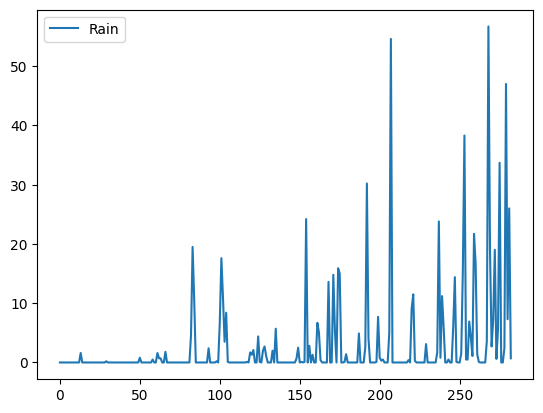

In [21]:
results["day"].plot(y="Rain")

<Axes: >

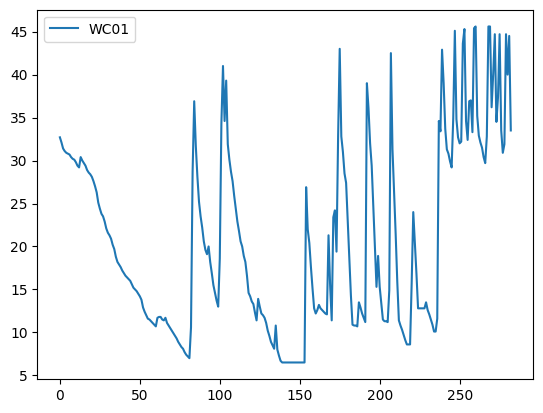

In [22]:
results["day"].plot(y="WC01")

<Axes: >

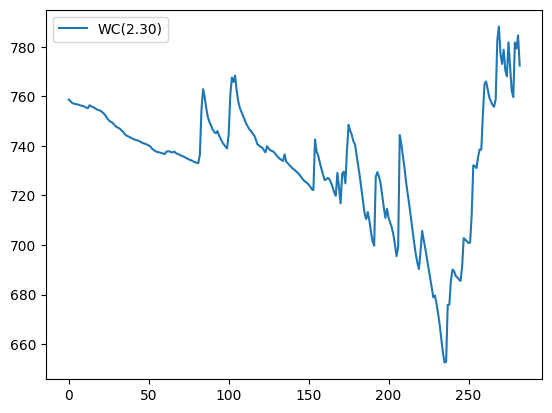

In [23]:
results["day"].plot(y="WC(2.30)")

<Axes: >

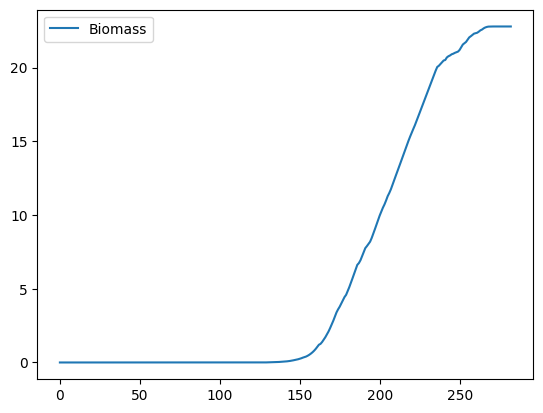

In [24]:
results["day"].plot(y="Biomass")

<Axes: >

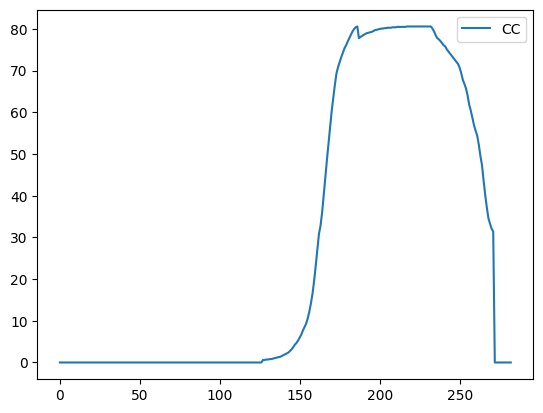

In [25]:
results["day"].plot(y="CC")

<Axes: >

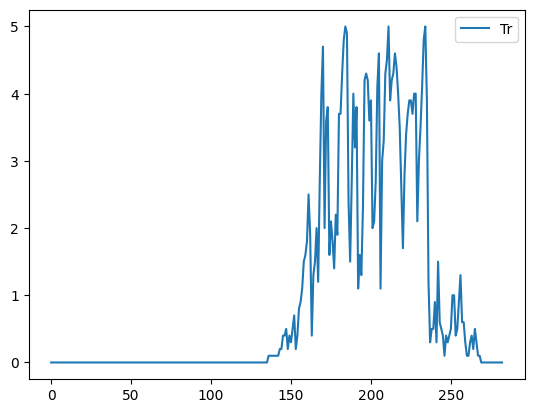

In [26]:
results["day"].plot(y="Tr")

<Axes: >

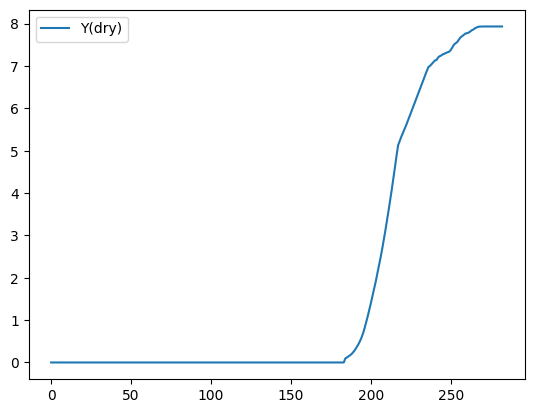

In [27]:
results["day"].plot(y="Y(dry)")